# 02 - Modeling

Predict 30-day readmission, but the thing I actually want is which factors drive it. I run a logistic regression because I can read the coefficients, then check whether gradient boosting does better.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score, classification_report

sns.set_style("whitegrid"); plt.rcParams["figure.dpi"] = 110

## Same cleaning as notebook 01
Keeping it identical so the model sees exactly what the EDA described.

In [2]:
df = pd.read_csv("../data/diabetic_data.csv")
df = df.sort_values("encounter_id").drop_duplicates("patient_nbr", keep="first")
df = df[~df["discharge_disposition_id"].isin([11,13,14,19,20,21])]
df = df.replace("?", np.nan)
df["readmit_30"] = (df["readmitted"] == "<30").astype(int)

df = df.drop(columns=["weight","payer_code","medical_specialty",
                      "encounter_id","patient_nbr","readmitted"])
print(f"Rows: {len(df):,} | positive rate: {df['readmit_30'].mean():.2%}")

Rows: 69,973 | positive rate: 8.97%


## Features
Scale the numbers, one-hot the categorical codes. I kept the feature set small on purpose so the coefficients stay readable.

In [3]:
num_cols = ["time_in_hospital","num_lab_procedures","num_procedures","num_medications",
            "number_outpatient","number_emergency","number_inpatient","number_diagnoses"]
cat_cols = ["race","gender","age","admission_type_id","discharge_disposition_id",
            "admission_source_id","A1Cresult","max_glu_serum","insulin","change","diabetesMed"]

for c in cat_cols:
    df[c] = df[c].astype(str)

X = df[num_cols + cat_cols]
y = df["readmit_30"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (52479, 19) Test: (17494, 19)


## Logistic regression first
`class_weight='balanced'` deals with the 9% positive rate. A bit of regularization (`C=0.1`) keeps the coefficients from going wild.

In [4]:
pre = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

logreg = Pipeline([
    ("pre", pre),
    ("lr", LogisticRegression(max_iter=1000, class_weight="balanced", C=0.1)),
])
logreg.fit(X_train, y_train)

proba_lr = logreg.predict_proba(X_test)[:, 1]
auc_lr = roc_auc_score(y_test, proba_lr)
ap_lr  = average_precision_score(y_test, proba_lr)
print(f"Logistic Regression  ROC-AUC: {auc_lr:.4f} | PR-AUC: {ap_lr:.4f}")

Logistic Regression  ROC-AUC: 0.6416 | PR-AUC: 0.1621


## Does boosting help?

In [5]:
pre_gb = ColumnTransformer([
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])
gb = Pipeline([
    ("pre", pre_gb),
    ("gb", HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05,
                                          max_depth=6, random_state=42)),
])
gb.fit(X_train, y_train)
proba_gb = gb.predict_proba(X_test)[:, 1]
auc_gb = roc_auc_score(y_test, proba_gb)
print(f"Gradient Boosting    ROC-AUC: {auc_gb:.4f}")
print(f"Logistic Regression  ROC-AUC: {auc_lr:.4f}")

Gradient Boosting    ROC-AUC: 0.6397
Logistic Regression  ROC-AUC: 0.6416


Boosting basically ties the logistic regression, so I'm keeping the one I can explain.

For context, this isn't under-fitting. Papers on this exact dataset land around 0.62-0.68 for the under-30-day target. Predicting early readmission from billing-style data is just hard.

## ROC curve

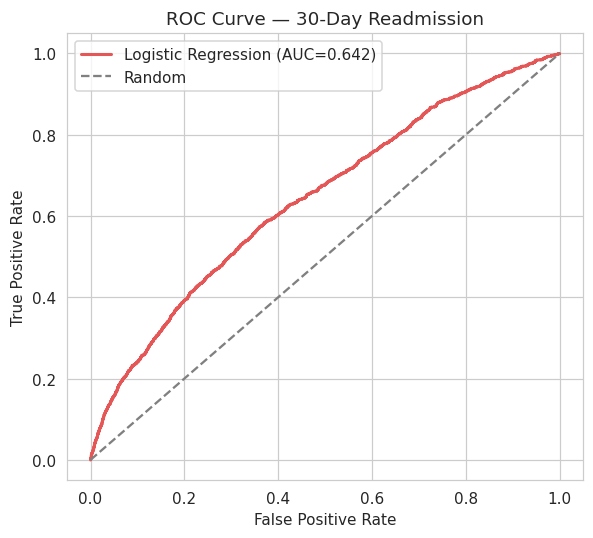

In [6]:
fpr, tpr, _ = roc_curve(y_test, proba_lr)
fig, ax = plt.subplots(figsize=(5.5,5))
ax.plot(fpr, tpr, color="#E45756", lw=2, label=f"Logistic Regression (AUC={auc_lr:.3f})")
ax.plot([0,1],[0,1],"--",color="gray",label="Random")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — 30-Day Readmission"); ax.legend()
plt.tight_layout(); plt.show()

## The actual point: what drives readmission
Logistic coefficients read as log-odds. Positive means more likely to come back.

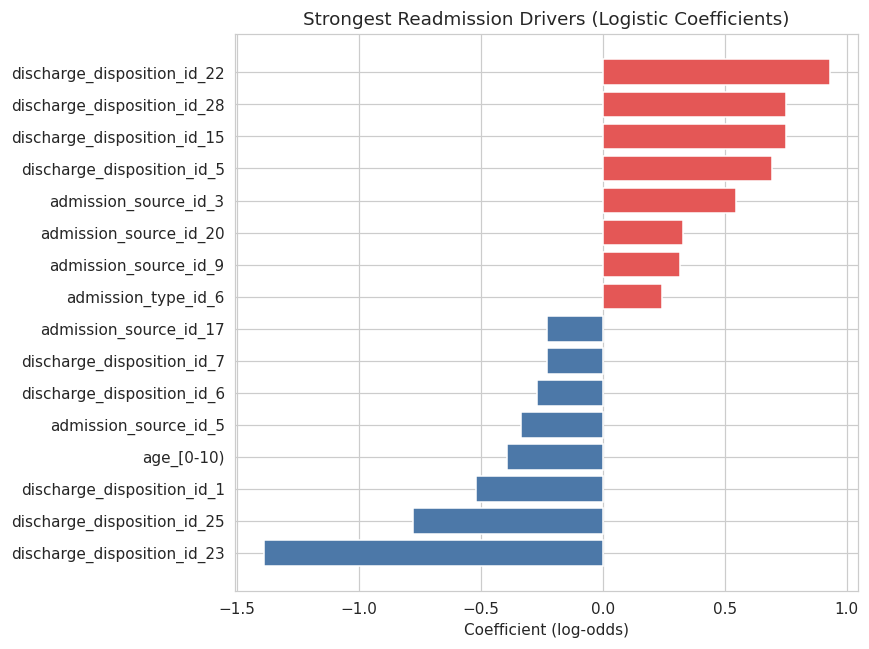

Top risk-INCREASING factors:
                    feature     coef
discharge_disposition_id_22 0.930253
discharge_disposition_id_28 0.750255
discharge_disposition_id_15 0.750077
 discharge_disposition_id_5 0.691899
      admission_source_id_3 0.545054
     admission_source_id_20 0.330077
      admission_source_id_9 0.315533
        admission_type_id_6 0.241047


In [7]:
ohe = logreg.named_steps["pre"].named_transformers_["cat"]
feat_names = num_cols + list(ohe.get_feature_names_out(cat_cols))
coefs = logreg.named_steps["lr"].coef_[0]

imp = pd.DataFrame({"feature": feat_names, "coef": coefs}).sort_values("coef")
top = pd.concat([imp.head(8), imp.tail(8)])

fig, ax = plt.subplots(figsize=(8,6))
colors = ["#E45756" if c > 0 else "#4C78A8" for c in top["coef"]]
ax.barh(top["feature"], top["coef"], color=colors)
ax.set_xlabel("Coefficient (log-odds)")
ax.set_title("Strongest Readmission Drivers (Logistic Coefficients)")
plt.tight_layout(); plt.show()

print("Top risk-INCREASING factors:")
print(imp.tail(8)[::-1].to_string(index=False))

## Wrap-up

Logistic regression, ~0.64 ROC-AUC. Boosting didn't beat it.

What pushes readmission risk up:
- Discharge disposition - where the patient goes next is the loudest signal.
- Prior inpatient visits - history repeats.
- Admission source/type - emergency and referral routes run hotter.
- Age - older bands skew higher.

Why a so-so model is still worth something: even at 0.64, ranking discharges by risk beats treating every discharge the same. A care team can follow up with the top slice instead of everyone.

Caveats, plainly: administrative data only, no lab trends or social factors, nothing post-discharge, and it's 1999-2008. The ceiling on this problem is low and the number reflects that.